In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
df = pd.read_csv("D:/PROJECT/NETWORK ANOMALY DETECTION/Data/balanced_dataset.csv")

C:\Users\prath\AppData\Local\Temp\ipykernel_3700\267796406.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("D:/PROJECT/NETWORK ANOMALY DETECTION/Data/balanced_dataset.csv")


In [62]:
df.head()

,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,175.45.176.3,47439,149.171.126.15,53,udp,INT,0.000009,114,0,254,...,,18,18,16,16,16,7,18,Generic,1
1,175.45.176.0,47439,149.171.126.10,53,udp,INT,0.000008,114,0,254,...,,16,16,16,16,16,16,16,Generic,1
2,59.166.0.0,23841,149.171.126.2,6881,tcp,FIN,0.252284,1540,1644,31,...,0,13,5,6,10,5,1,5,NaN,0
3,59.166.0.6,11062,149.171.126.1,6881,tcp,FIN,2.888732,12242,497036,31,...,0,13,12,3,5,1,1,1,NaN,0
4,175.45.176.0,1043,149.171.126.12,53,udp,INT,0.000009,114,0,254,...,,17,17,8,9,8,8,17,Generic,1


In [63]:
rename_map = {
    'srcip': 'Source_IP_Address',
    'sport': 'Source_Port',
    'dstip': 'Destination_IP_Address',
    'dsport': 'Destination_Port',
    'proto': 'Protocol',
    'state': 'Connection_State',
    'dur': 'Connection_Duration',
    'sbytes': 'Src_to_Dst_Bytes',
    'dbytes': 'Dst_to_Src_Bytes',
    'sttl': 'Src_TTL',
    'dttl': 'Dst_TTL',
    'sloss': 'Src_Packet_Retransmissions',
    'dloss': 'Dst_Packet_Retransmissions',
    'service': 'Service_Type',
    'Sload': 'Src_Bits_per_Sec',
    'Dload': 'Dst_Bits_per_Sec',
    'Spkts': 'Src_to_Dst_Packet_Count',
    'Dpkts': 'Dst_to_Src_Packet_Count',
    'swin': 'Src_TCP_Window_Advertised',
    'dwin': 'Dst_TCP_Window_Advertised',
    'stcpb': 'Src_TCP_Base_Seq_Num',
    'dtcpb': 'Dst_TCP_Base_Seq_Num',
    'smeansz': 'Src_Mean_Packet_Size',
    'dmeansz': 'Dst_Mean_Packet_Size',
    'trans_depth': 'HTTP_Pipelined_Depth',
    'res_bdy_len': 'HTTP_Content_Size',
    'Sjit': 'Src_Jitter_ms',
    'Djit': 'Dst_Jitter_ms',
    'Stime': 'Record_Start_Time',
    'Ltime': 'Record_End_Time',
    'Sintpkt': 'Src_Interpacket_Arrival_ms',
    'Dintpkt': 'Dst_Interpacket_Arrival_ms',
    'tcprtt': 'TCP_RTT',
    'synack': 'TCP_SYN_ACK_Time',
    'ackdat': 'TCP_ACK_Delay',
    'is_sm_ips_ports': 'Same_IP_and_Port_Flag',
    'ct_state_ttl': 'CT_State_TTL_Count',
    'ct_flw_http_mthd': 'CT_Flw_HTTP_Method_Count',
    'is_ftp_login': 'Is_FTP_Login',
    'ct_ftp_cmd': 'CT_FTP_Command_Count',
    'ct_srv_src': 'CT_Same_Service_Src_Count',
    'ct_srv_dst': 'CT_Same_Service_Dst_Count',
    'ct_dst_ltm': 'CT_Same_Dst_Count',
    'ct_src_ ltm': 'CT_Same_Src_Count',
    'ct_src_dport_ltm': 'CT_Same_Src_Dport_Count',
    'ct_dst_sport_ltm': 'CT_Same_Dst_Sport_Count',
    'ct_dst_src_ltm': 'CT_Same_SrcDst_Pair_Count',
    'attack_cat': 'Attack_Category',
    'Label': 'Label'
}

# Apply renaming
df.rename(columns=rename_map, inplace=True)

print("✅ Columns renamed successfully!")
print(df.columns.tolist())


✅ Columns renamed successfully!
['Source_IP_Address', 'Source_Port', 'Destination_IP_Address', 'Destination_Port', 'Protocol', 'Connection_State', 'Connection_Duration', 'Src_to_Dst_Bytes', 'Dst_to_Src_Bytes', 'Src_TTL', 'Dst_TTL', 'Src_Packet_Retransmissions', 'Dst_Packet_Retransmissions', 'Service_Type', 'Src_Bits_per_Sec', 'Dst_Bits_per_Sec', 'Src_to_Dst_Packet_Count', 'Dst_to_Src_Packet_Count', 'Src_TCP_Window_Advertised', 'Dst_TCP_Window_Advertised', 'Src_TCP_Base_Seq_Num', 'Dst_TCP_Base_Seq_Num', 'Src_Mean_Packet_Size', 'Dst_Mean_Packet_Size', 'HTTP_Pipelined_Depth', 'HTTP_Content_Size', 'Src_Jitter_ms', 'Dst_Jitter_ms', 'Record_Start_Time', 'Record_End_Time', 'Src_Interpacket_Arrival_ms', 'Dst_Interpacket_Arrival_ms', 'TCP_RTT', 'TCP_SYN_ACK_Time', 'TCP_ACK_Delay', 'Same_IP_and_Port_Flag', 'CT_State_TTL_Count', 'CT_Flw_HTTP_Method_Count', 'Is_FTP_Login', 'CT_FTP_Command_Count', 'CT_Same_Service_Src_Count', 'CT_Same_Service_Dst_Count', 'CT_Same_Dst_Count', 'CT_Same_Src_Count', 'C

In [65]:
print(df['Attack_Category'].unique())

['Generic' nan 'Exploits' 'Reconnaissance' 'Backdoor' ' Reconnaissance '
 'Worms' ' Fuzzers' ' Fuzzers ' 'DoS' ' Shellcode ' 'Backdoors' 'Analysis'
 'Shellcode']


In [66]:
df.drop(columns=['attack_cat'], inplace=True)

KeyError: "['attack_cat'] not found in axis"

In [67]:
df.describe()

,Source_Port,Connection_Duration,Src_to_Dst_Bytes,Dst_to_Src_Bytes,Src_TTL,Dst_TTL,Src_Packet_Retransmissions,Dst_Packet_Retransmissions,Src_Bits_per_Sec,Dst_Bits_per_Sec,...,CT_Flw_HTTP_Method_Count,Is_FTP_Login,CT_Same_Service_Src_Count,CT_Same_Service_Dst_Count,CT_Same_Dst_Count,CT_Same_Src_Count,CT_Same_Src_Dport_Count,CT_Same_Dst_Sport_Count,CT_Same_SrcDst_Pair_Count,Label
count,642566.000000,642566.000000,6.425660e+05,6.425660e+05,642566.000000,642566.000000,642566.000000,642566.000000,6.425660e+05,6.425660e+05,...,205167.000000,181306.000000,642566.000000,642566.000000,642566.000000,642566.000000,642566.000000,642566.000000,642566.000000,642566.0
mean,27078.200709,0.708157,4.991627e+03,2.270150e+04,138.578412,37.251915,4.067998,10.213592,6.253669e+07,1.405393e+06,...,0.292289,0.044714,13.864756,13.688318,9.555576,10.064208,8.422103,6.499262,12.408142,0.5
std,21982.951248,16.005236,1.106262e+05,1.435766e+05,109.316688,71.669496,42.088197,51.448020,1.384209e+08,3.418505e+06,...,0.975580,0.212752,13.828059,13.890368,10.608375,10.602852,11.042721,7.867789,14.585408,0.5
min,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0
25%,1043.000000,0.000008,1.140000e+02,0.000000e+00,31.000000,0.000000,0.000000,0.000000,2.978112e+05,0.000000e+00,...,0.000000,0.000000,3.000000,3.000000,2.000000,2.000000,1.000000,1.000000,1.000000,0.0
50%,27787.000000,0.001058,2.640000e+02,1.780000e+02,62.000000,29.000000,0.000000,0.000000,1.830443e+06,3.881689e+03,...,0.000000,0.000000,7.000000,7.000000,4.000000,5.000000,2.000000,1.000000,4.000000,0.5
75%,47439.000000,0.100802,2.054000e+03,3.276000e+03,254.000000,29.000000,4.000000,5.000000,7.600000e+07,6.592593e+05,...,0.000000,0.000000,24.000000,24.000000,16.000000,16.000000,16.000000,13.000000,24.000000,1.0
max,65535.000000,8760.776367,1.435577e+07,1.465753e+07,255.000000,254.000000,5319.000000,5507.000000,5.988000e+09,1.287619e+08,...,36.000000,4.000000,67.000000,67.000000,67.000000,67.000000,67.000000,60.000000,67.000000,1.0


In [68]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)


Shape: (642566, 49)

Data Types:
 Source_IP_Address              object
Source_Port                     int64
Destination_IP_Address         object
Destination_Port               object
Protocol                       object
Connection_State               object
Connection_Duration           float64
Src_to_Dst_Bytes                int64
Dst_to_Src_Bytes                int64
Src_TTL                         int64
Dst_TTL                         int64
Src_Packet_Retransmissions      int64
Dst_Packet_Retransmissions      int64
Service_Type                   object
Src_Bits_per_Sec              float64
Dst_Bits_per_Sec              float64
Src_to_Dst_Packet_Count         int64
Dst_to_Src_Packet_Count         int64
Src_TCP_Window_Advertised       int64
Dst_TCP_Window_Advertised       int64
Src_TCP_Base_Seq_Num            int64
Dst_TCP_Base_Seq_Num            int64
Src_Mean_Packet_Size            int64
Dst_Mean_Packet_Size            int64
HTTP_Pipelined_Depth            int64
HTTP_Content_Siz

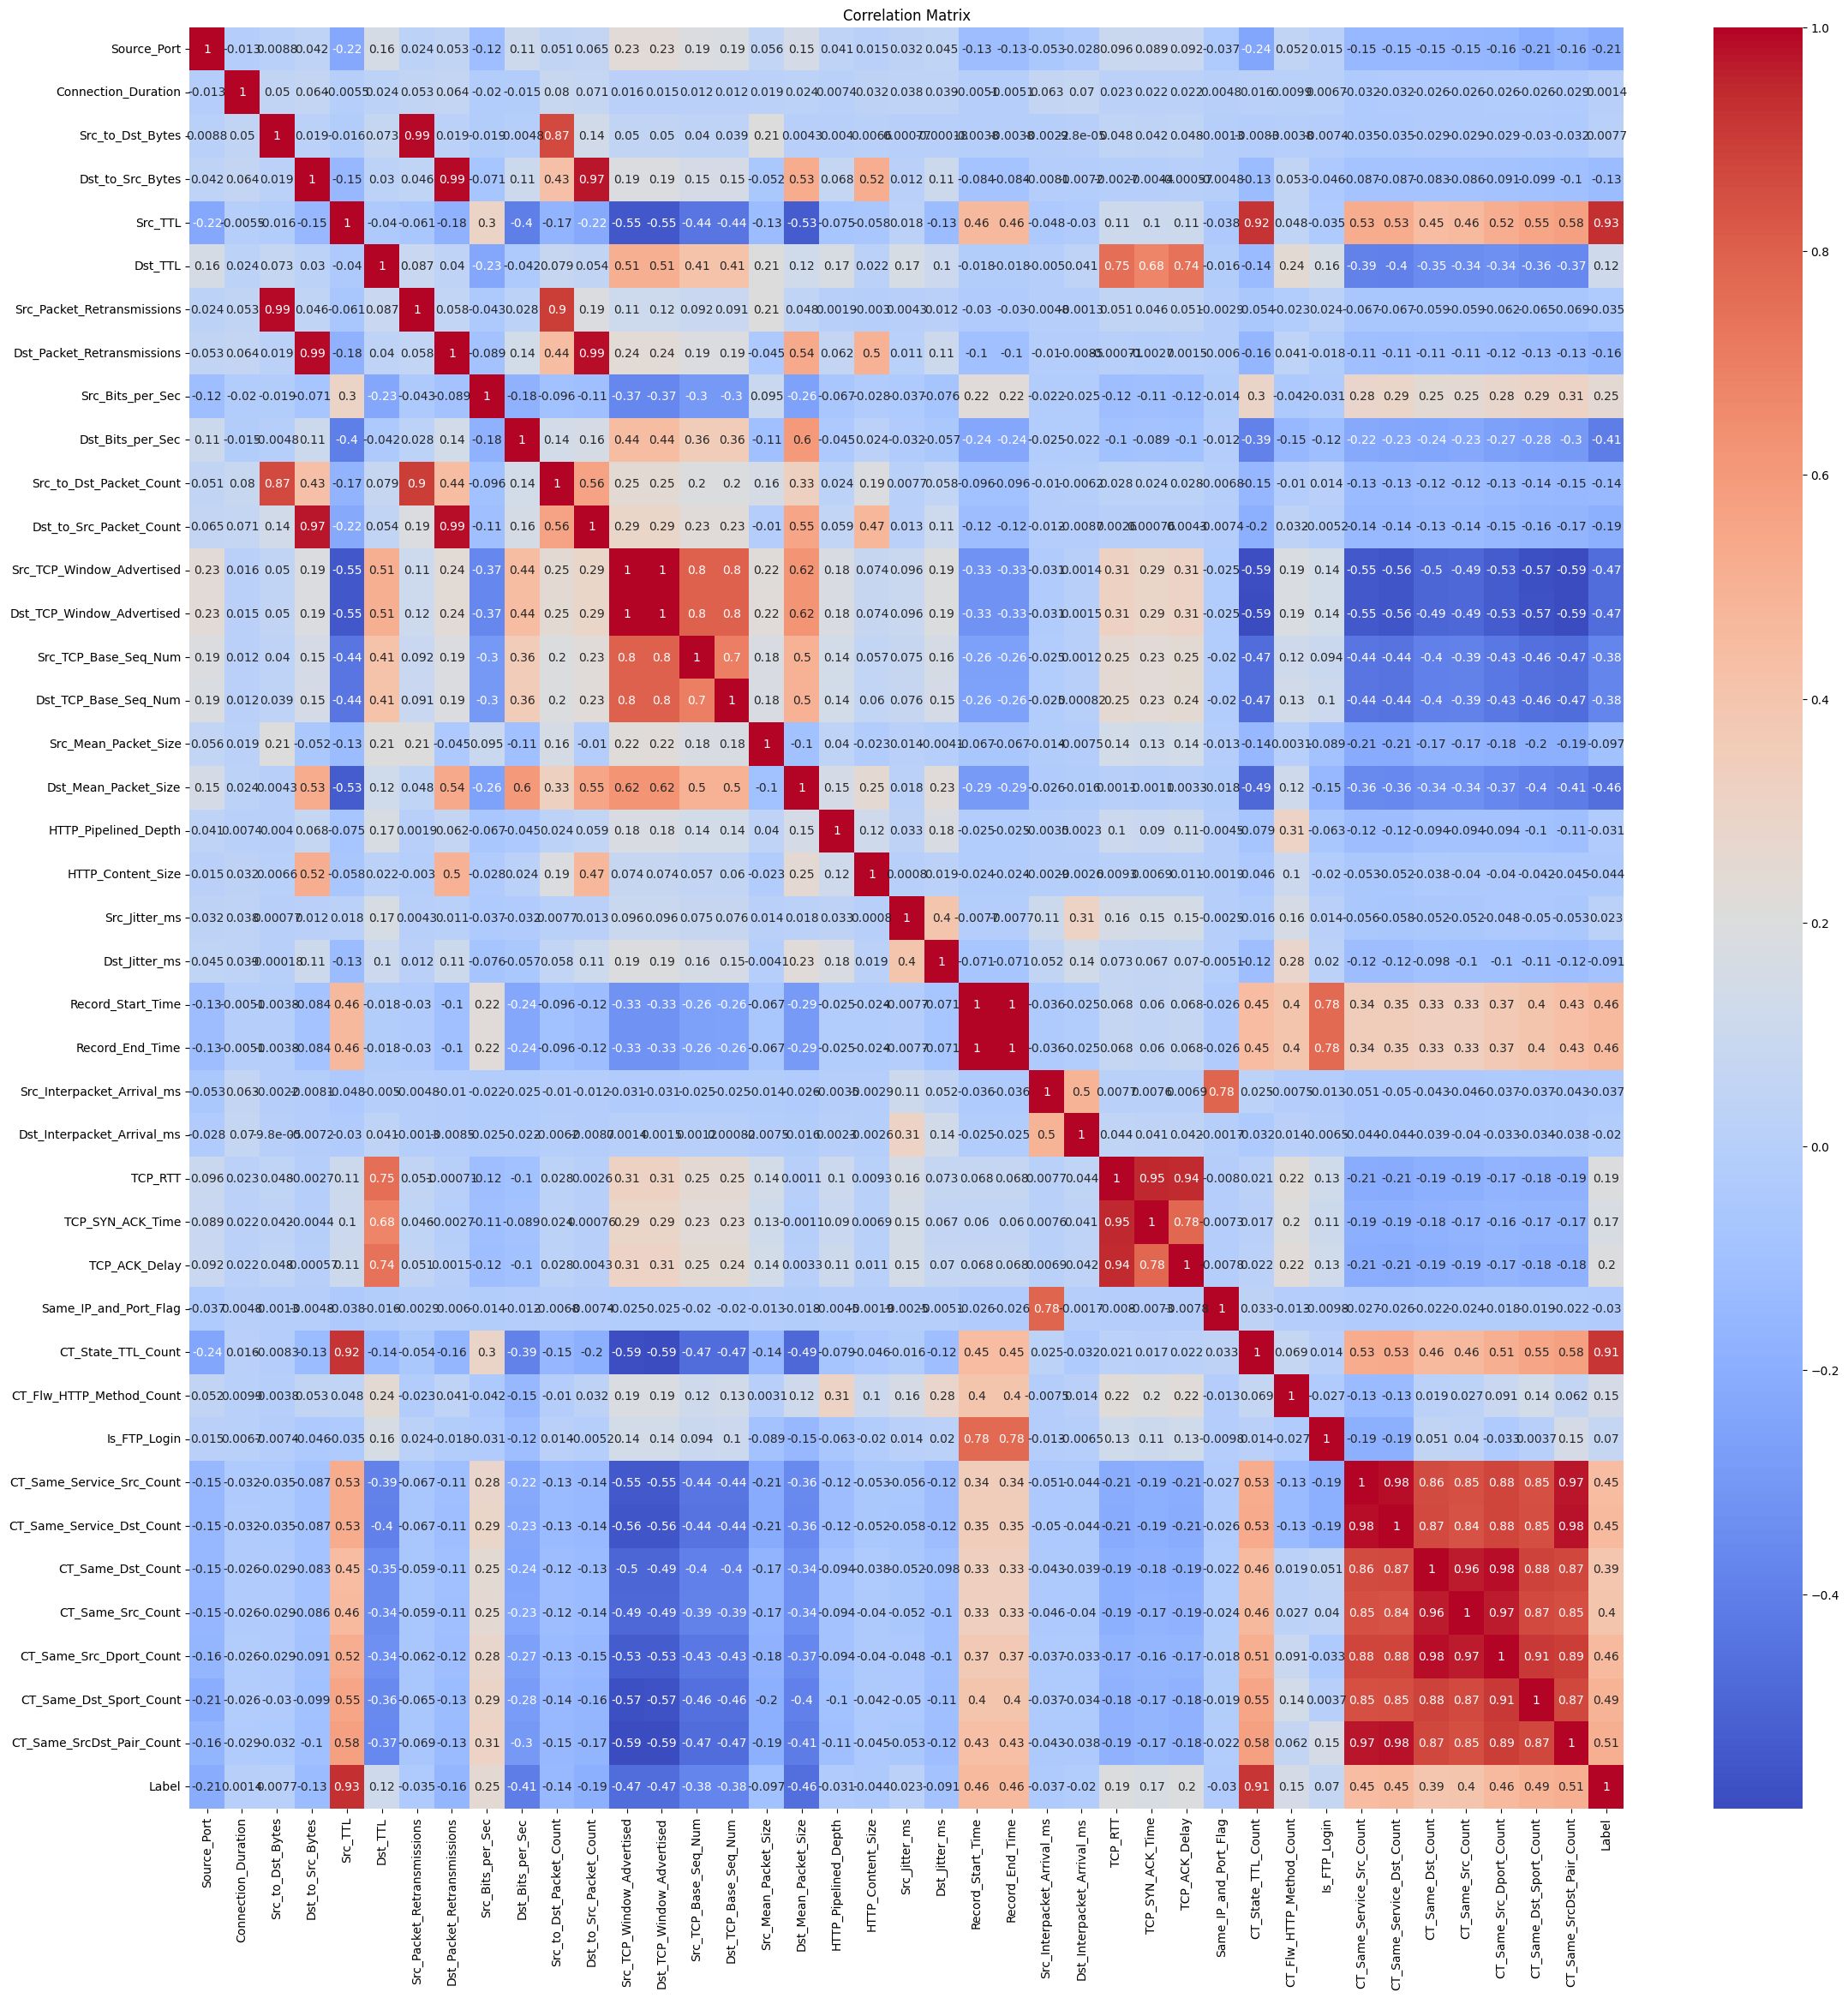

In [69]:
plt.figure(figsize=(27,27))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [70]:
df.to_csv('preprocessed_data.csv', index=True)